# BDD100K Scene Classification — Combined Feature Extraction


In [20]:
# ============================================================
# All imports for the BDD100K feature extraction + classification pipeline
# ============================================================

# Standard library
import os
import glob
import json
import time

# Google Colab
from google.colab import drive

# Core data handling
import numpy as np
import pandas as pd

# Image processing
import cv2
from skimage.feature import hog, local_binary_pattern
from skimage.feature import hog as hog_vis   # aliased for the illustration cell

# Deep learning / ResNet feature extraction
import torch
import torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader

# Dimensionality reduction / visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Progress bars
from tqdm import tqdm

print("All imports loaded successfully")

All imports loaded successfully


## 1. Mount Drive and locate the shared project folder

In [21]:
from google.colab import drive
drive.mount('/content/drive')

import glob
hits = glob.glob('/content/drive/MyDrive/DATASCI 281*/BDD100k DATA')
print(hits)
BASE = hits[0]
print("BASE =", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['/content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA']
BASE = /content/drive/MyDrive/DATASCI 281 Group Project/BDD100k DATA


## 2. Load the manifest and build the shared dev sample


## 2a. Try loading cached features first (skip re-extraction if already saved)
Run this every time you open the notebook. If `features_full.npz` already exists on Drive
from a previous run, this loads it directly and sets `FEATURES_LOADED = True` — Sections 3, 3a,
6, and 7 (unzip + extraction + re-save) can then be skipped entirely.

Note: Sections 8 and 9 (image illustrations, brightness plot) still need the *raw images*
unzipped in this session regardless of whether features are cached, since they display actual
pictures rather than just feature numbers. Only run 3/3a if you need those, or if this cell
reports no cache found.

In [22]:
import os
import numpy as np

FEATURES_CACHE = f'{BASE}/features_full.npz'

if os.path.exists(FEATURES_CACHE):
    print("Found cached features on Drive — loading instead of re-extracting.")
    data = np.load(FEATURES_CACHE, allow_pickle=True)
    results = {name: {'X': data[name]} for name in data.files if name != 'y'}
    y = data['y']
    FEATURES_LOADED = True
    print("Loaded feature types:", list(results.keys()))
    for name in results:
        print(f"  {name}: shape={results[name]['X'].shape}")
else:
    print("No cached features found on Drive yet — need to run extraction (Sections 3-7 below).")
    FEATURES_LOADED = False

Found cached features on Drive — loading instead of re-extracting.
Loaded feature types: ['hsv_regions', 'hog', 'lbp', 'global_rgb', 'global_hsv', 'region_rgb', 'resnet']
  hsv_regions: shape=(4217, 144)
  hog: shape=(4217, 4320)
  lbp: shape=(4217, 10)
  global_rgb: shape=(4217, 48)
  global_hsv: shape=(4217, 48)
  region_rgb: shape=(4217, 144)
  resnet: shape=(4217, 2048)


In [23]:
import pandas as pd

df = pd.read_csv(f'{BASE}/scene_manifest.csv')
print(df['scene'].value_counts())

CAP = 1200
sample = (df.groupby('scene', group_keys=False)
            .apply(lambda g: g.sample(min(len(g), CAP), random_state=42))
            .reset_index(drop=True))
print(sample['scene'].value_counts())
print(len(sample), "images in dev sample")

scene
city street     49693
highway         19913
residential      9358
parking lot       427
tunnel            156
gas stations       34
Name: count, dtype: int64
scene
city street     1200
highway         1200
residential     1200
parking lot      427
tunnel           156
gas stations      34
Name: count, dtype: int64
4217 images in dev sample


/tmp/ipykernel_3234/3554300430.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), CAP), random_state=42))


## 3. Verify images are reachable (unzip if this is a fresh session)
Run the check first. If it reports missing files, run the unzip + rename cells below, then re-check.

In [24]:
import os

missing = sum(not os.path.exists(p) for p in sample['img_path'].head(20))
print(f"{missing}/20 checked — should be 0")

20/20 checked — should be 0


### 3a. Only run this if step 3 showed missing images

In [38]:
import os

if os.path.exists('/content/data/100k_images') or os.path.exists('/content/data/100k'):
    print("Images already unzipped in this session — skipping.")
else:
    !unzip -q "{BASE}/bdd100k_images_100k.zip" -d /content/data

Images already unzipped in this session — skipping.


In [39]:
import os
# Colab's extracted folder is sometimes named '100k' instead of '100k_images'
if os.path.exists('/content/data/100k') and not os.path.exists('/content/data/100k_images'):
    os.rename('/content/data/100k', '/content/data/100k_images')

missing = sum(not os.path.exists(p) for p in sample['img_path'].head(20))
print(f"{missing}/20 checked — should be 0")

0/20 checked — should be 0


In [40]:
def random_crop(image: np.ndarray, crop_size: tuple[int, int], rng=None) -> np.ndarray:
    """
    Randomly crop an image.

    Parameters
    ----------
    image : np.ndarray
        Image of shape (H, W, C).
    crop_size : tuple[int, int]
        Desired crop size as (crop_height, crop_width).
    rng : np.random.Generator, optional
        Random number generator. If None, a new default generator is used.

    Returns
    -------
    np.ndarray
        Cropped image of shape (crop_height, crop_width, C).
    """
    if rng is None:
        rng = np.random.default_rng()

    H, W = image.shape[:2]
    crop_h, crop_w = crop_size

    if crop_h > H or crop_w > W:
        raise ValueError(
            f"Crop size {(crop_h, crop_w)} exceeds image size {(H, W)}."
        )

    top = rng.integers(0, H - crop_h + 1)
    left = rng.integers(0, W - crop_w + 1)

    return image[top:top + crop_h, left:left + crop_w]

## 4. Feature extraction functions
Combined from both notebooks. `feat_hsv_regions` (region-wise HSV, the team's primary color feature) is identical to what would otherwise be called `feat_region_hsv` in the ablation — kept under one name to avoid duplicate computation.

In [41]:
import cv2
import numpy as np
from skimage.feature import hog, local_binary_pattern

IMG_W, IMG_H = 256, 144   # keep 16:9, small enough to be fast

def load_img(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (IMG_W, IMG_H))

# --- Primary features

def feat_hsv_regions(img, bins=16):
    """Region-wise HSV histograms over top/middle/bottom bands. (= region_hsv in the ablation)"""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    h = img.shape[0]
    bands = [hsv[:h//3], hsv[h//3:2*h//3], hsv[2*h//3:]]
    feats = []
    for band in bands:
        for ch in range(3):
            hist = cv2.calcHist([band], [ch], None, [bins], [0, 256]).flatten()
            feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 bands x 3 ch x 16 bins = 144 dims

def feat_hog(img):
    """HOG on grayscale — edge density/orientation."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return hog(gray, orientations=9, pixels_per_cell=(16, 16),
               cells_per_block=(2, 2), feature_vector=True)

def feat_lbp(img, P=8, R=1):
    """Uniform LBP histogram — micro-texture, cheap."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    lbp = local_binary_pattern(gray, P, R, method='uniform')
    hist, _ = np.histogram(lbp, bins=P+2, range=(0, P+2))
    return hist / (hist.sum() + 1e-8)

# --- Color histogram ablation (additional variants) ---

def feat_global_rgb(img, bins=16):
    """Whole-image RGB histogram — no spatial split."""
    feats = []
    for ch in range(3):
        hist = cv2.calcHist([img], [ch], None, [bins], [0, 256]).flatten()
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 ch x 16 bins = 48 dims

def feat_global_hsv(img, bins=16):
    """Whole-image HSV histogram — no spatial split."""
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    feats = []
    for ch in range(3):
        hist = cv2.calcHist([hsv], [ch], None, [bins], [0, 256]).flatten()
        feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 ch x 16 bins = 48 dims

def feat_region_rgb(img, bins=16):
    """Region-wise RGB: top/middle/bottom bands, RGB (no hue/brightness separation)."""
    h = img.shape[0]
    bands = [img[:h//3], img[h//3:2*h//3], img[2*h//3:]]
    feats = []
    for band in bands:
        for ch in range(3):
            hist = cv2.calcHist([band], [ch], None, [bins], [0, 256]).flatten()
            feats.append(hist / (hist.sum() + 1e-8))
    return np.concatenate(feats)          # 3 bands x 3 ch x 16 bins = 144 dims


def hough_orientation_histogram(
    image,
    bins=18,
    canny_low=50,
    canny_high=150,
    hough_threshold=50,
    min_line_length=30,
    max_line_gap=10,
    normalize=True,
    weight_by_length=True,
):
    """
    Computes a histogram of Hough line orientations.

    Parameters
    ----------
    image : ndarray
        Input image (grayscale or BGR).
    bins : int
        Number of orientation bins over [0, 180).
    normalize : bool
        Normalize histogram to sum to 1.
    weight_by_length : bool
        Weight each line by its length.

    Returns
    -------
    hist : ndarray
        Orientation histogram.
    angles : ndarray
        Angle of every detected line (degrees).
    lengths : ndarray
        Length of every detected line.
    """

    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image.copy()

    # Edge detection
    edges = cv2.Canny(gray, canny_low, canny_high)

    # Detect line segments
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=hough_threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap,
    )

    hist = np.zeros(bins, dtype=np.float32)

    if lines is None:
        return hist

    angles = []
    lengths = []

    for line in lines:
        x1, y1, x2, y2 = line[0]

        dx = x2 - x1
        dy = y2 - y1

        length = np.hypot(dx, dy)

        angle = np.degrees(np.arctan2(dy, dx))

        # Convert to [0,180)
        angle = angle % 180

        bin_index = int(angle / 180 * bins)
        bin_index = min(bin_index, bins - 1)

        if weight_by_length:
            hist[bin_index] += length
        else:
            hist[bin_index] += 1

    if normalize and hist.sum() > 0:
        hist /= hist.sum()

    return hist

def feat_hough(img, bins=18):
    """Hough line-orientation histogram — structural line/angle distribution."""
    return hough_orientation_histogram(img, bins=bins)

## 5. ResNet50 setup (complex feature)

In [42]:
import torch, torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("CUDA available:", torch.cuda.is_available())

weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)
model.fc = torch.nn.Identity()          # 2048-dim penultimate embeddings
model = model.eval().to(device)
preprocess = weights.transforms()

class ImgDS(Dataset):
    def __init__(self, paths): self.paths = paths
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = load_img(self.paths[i])
        return preprocess(torch.from_numpy(img).permute(2,0,1))

@torch.no_grad()
def extract_resnet(paths, bs=64):
    dl = DataLoader(ImgDS(paths), batch_size=bs, num_workers=2)
    out = [model(b.to(device)).cpu().numpy() for b in dl]
    return np.vstack(out)

CUDA available: False


## 6. Run all extraction, with timing
Loads every image once, then runs all 6 simple-feature extractors plus ResNet over the same cached images.

In [43]:
if not FEATURES_LOADED:
    import time
    from tqdm import tqdm

    extractors = {
        'hsv_regions': feat_hsv_regions,
        'hog': feat_hog,
        'lbp': feat_lbp,
        'global_rgb': feat_global_rgb,
        'global_hsv': feat_global_hsv,
        'region_rgb': feat_region_rgb,
        'hough': feat_hough,
    }

    imgs_cache = [load_img(p) for p in tqdm(sample['img_path'], desc='loading images')]

    results = {}
    for name, fn in extractors.items():
        t0 = time.time()
        X = np.array([fn(img) for img in imgs_cache])
        elapsed = time.time() - t0
        results[name] = {'X': X, 'time_sec': elapsed}
        print(f"{name}: shape={X.shape}, time={elapsed:.1f}s "
              f"({elapsed/len(imgs_cache)*1000:.2f} ms/image)")

    t0 = time.time()
    X_resnet = extract_resnet(sample['img_path'].tolist())
    elapsed = time.time() - t0
    results['resnet'] = {'X': X_resnet, 'time_sec': elapsed}
    print(f"resnet: shape={X_resnet.shape}, time={elapsed:.1f}s "
          f"({elapsed/len(imgs_cache)*1000:.2f} ms/image)")

    y = sample['scene'].values

else:
    print("Using cached features — skipping extraction.")


Using cached features — skipping extraction.


## 7. Save everything to Drive
One combined cache file with all 7 feature types, plus a timing table for the Efficiency vs Accuracy section.

In [44]:
if not FEATURES_LOADED:
    np.savez(f'{BASE}/features_full.npz',
             hsv_regions=results['hsv_regions']['X'],
             hog=results['hog']['X'],
             lbp=results['lbp']['X'],
             global_rgb=results['global_rgb']['X'],
             global_hsv=results['global_hsv']['X'],
             region_rgb=results['region_rgb']['X'],
             hough=results['hough']['X'],
             resnet=results['resnet']['X'],
             y=y)

    timing_df = pd.DataFrame({
        'feature': list(results.keys()),
        'dims': [results[k]['X'].shape[1] for k in results],
        'total_time_sec': [round(results[k]['time_sec'], 2) for k in results],
        'ms_per_image': [round(results[k]['time_sec']/len(imgs_cache)*1000, 3) for k in results],
    })
    timing_df.to_csv(f'{BASE}/features_full_timing.csv', index=False)
    print(timing_df)
else:
    print("Using cached features — skipping save (already on Drive).")

Using cached features — skipping save (already on Drive).


## 8. Feature illustrations (HOG / LBP per class)

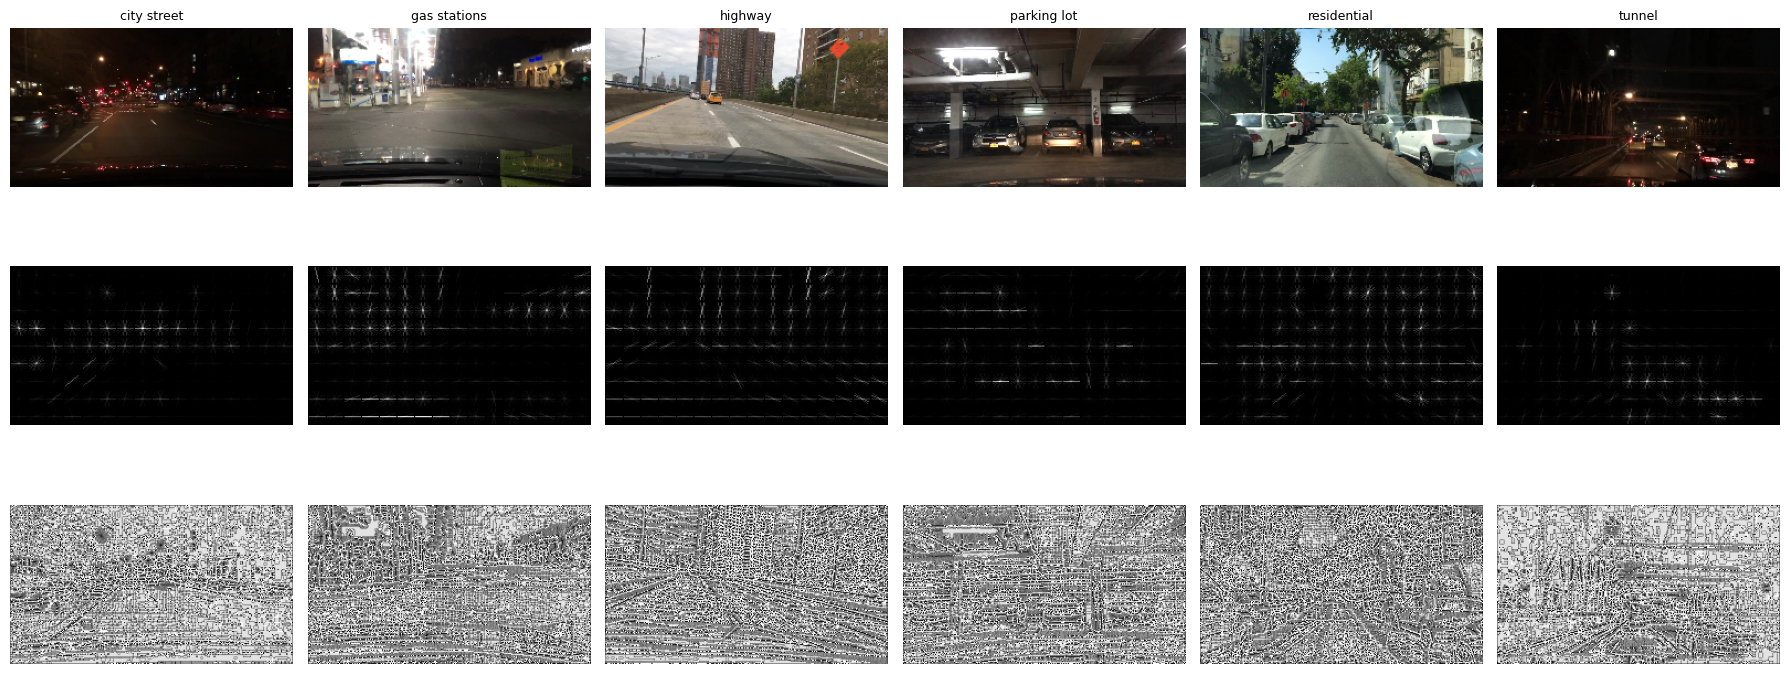

In [45]:
import matplotlib.pyplot as plt
from skimage.feature import hog as hog_vis

classes = sorted(sample['scene'].unique())
fig, axes = plt.subplots(3, len(classes), figsize=(3*len(classes), 8))
for j, c in enumerate(classes):
    p = sample[sample['scene'] == c]['img_path'].iloc[0]
    img = load_img(p)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, hog_img = hog_vis(gray, orientations=9, pixels_per_cell=(16,16),
                         cells_per_block=(2,2), visualize=True)
    lbp = local_binary_pattern(gray, 8, 1, method='uniform')
    axes[0, j].imshow(img);              axes[0, j].set_title(c, fontsize=9)
    axes[1, j].imshow(hog_img, cmap='gray')
    axes[2, j].imshow(lbp, cmap='gray')
    for i in range(3): axes[i, j].axis('off')
axes[0,0].set_ylabel('Original'); axes[1,0].set_ylabel('HOG'); axes[2,0].set_ylabel('LBP')
plt.tight_layout(); plt.show()

## 9. Dataset variation: mean brightness by class

100%|██████████| 4217/4217 [00:12<00:00, 334.34it/s]


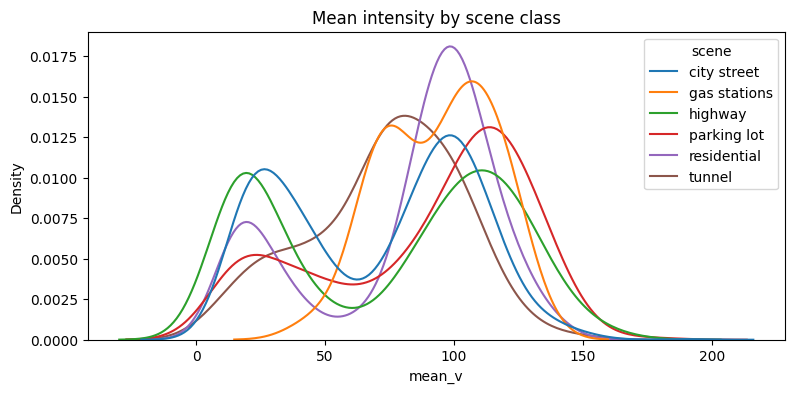

In [46]:
import seaborn as sns

sample['mean_v'] = [load_img(p)[:,:,:].mean() for p in tqdm(sample['img_path'])]
plt.figure(figsize=(9,4))
sns.kdeplot(data=sample, x='mean_v', hue='scene', common_norm=False)
plt.title('Mean intensity by scene class'); plt.show()

## 10. PCA explained variance — all 7 feature types

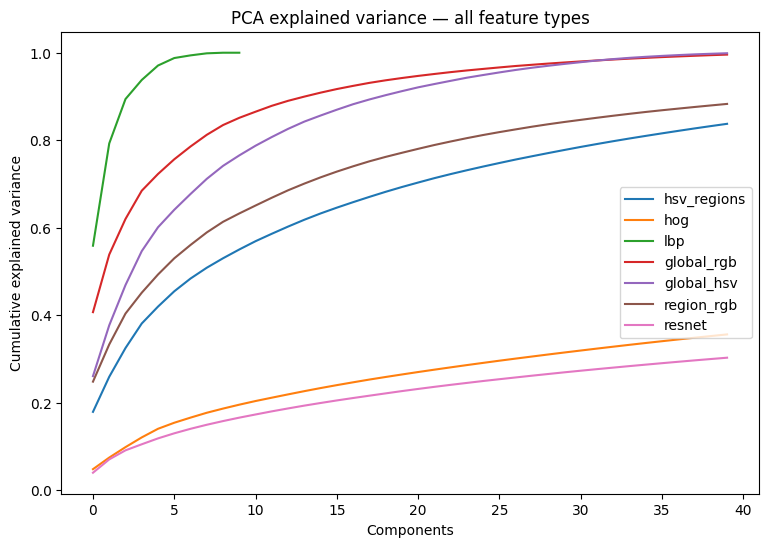

In [47]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(9, 6))
for name in results:
    Xs = StandardScaler().fit_transform(results[name]['X'])
    n_comp = min(40, Xs.shape[1])
    pca = PCA(n_components=n_comp).fit(Xs)
    plt.plot(np.cumsum(pca.explained_variance_ratio_), label=name)
plt.xlabel('Components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.title('PCA explained variance — all feature types')
plt.show()

## 11. t-SNE — all 7 feature types side by side

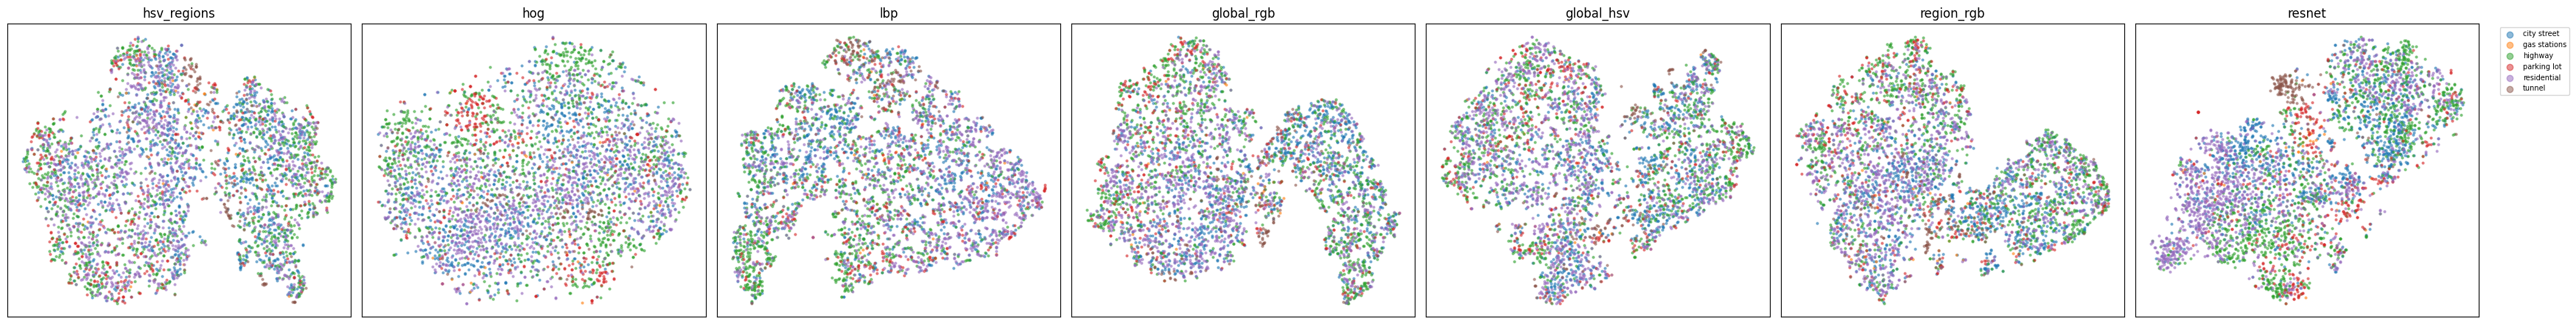

In [48]:
from sklearn.manifold import TSNE

feature_names = list(results.keys())
fig, axes = plt.subplots(1, len(feature_names), figsize=(5*len(feature_names), 4.5))
for ax, name in zip(axes, feature_names):
    Xs = StandardScaler().fit_transform(results[name]['X'])
    n_comp = min(30, Xs.shape[1])
    Xp = PCA(n_components=n_comp).fit_transform(Xs)
    emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(Xp)
    for c in classes:
        m = y == c
        ax.scatter(emb[m, 0], emb[m, 1], s=4, alpha=0.5, label=c)
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(markerscale=3, fontsize=7, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 12. Feature summary table

| Feature | Type | Dims | What it captures |
|---|---|---|---|
| Region-wise HSV histograms | Simple (primary) | 144 | Color distribution over top/middle/bottom bands — sky-structure-road stratification. |
| Histogram of Oriented Gradients (HOG) | Simple | 4,320 | Edge density and orientation — structural layout. |
| Local Binary Patterns (LBP) | Simple | 10 | Micro-texture — cheap, efficiency-side baseline. |
| Global RGB histogram | Simple (ablation) | 48 | Whole-image color distribution, no spatial info. Highest PCA compressibility. |
| Global HSV histogram | Simple (ablation) | 48 | Whole-image color, brightness/hue separated. |
| Region-wise RGB histogram | Simple (ablation) | 144 | Top/middle/bottom band color, no hue/brightness separation. |
| ResNet50 embeddings | Complex | 2,048 | Penultimate-layer activations of an ImageNet-pretrained CNN. |

## 13. Color histogram ablation — write-up

**Color histogram ablation: global vs. region-wise, RGB vs. HSV.** To validate the design choice of region-wise HSV histograms over simpler alternatives, we extracted four color-histogram variants on the same dev sample (global RGB, global HSV, region-wise RGB, region-wise HSV) and compared them via PCA and t-SNE. PCA explained-variance curves show global histograms are substantially more compressible than region-wise ones (reaching ~100% cumulative variance by ~35 components vs. ~85-88% for region-wise at the same budget), and RGB compresses faster than HSV within each grouping. This is consistent with expectation rather than a weakness: RGB's channels are correlated (brightness shifts move R, G, and B together), so early components capture most of its variance, while HSV's explicit separation of hue from brightness — and region-wise splitting's deliberate capture of distinct top/middle/bottom information — spread real signal across more dimensions instead of compressing away information. t-SNE visualization, however, shows all four variants produce heavily overlapping class clusters, with none approaching the separation seen in the ResNet embeddings. The clearest partial separation appears between city street and highway (consistent with their differing openness and color composition) and small tunnel sub-clusters (consistent with tunnels' distinctive dark, artificially-lit color signature), while residential, parking lot, and gas stations show essentially no visual separation in any variant — likely compounded by the severe sample scarcity in the latter two classes. Region-wise histograms did not show a clear visual separability advantage over global histograms in 2D t-SNE space despite carrying more non-redundant information per PCA. This confirms that color alone provides weak-to-moderate signal for scene classification — sufficient for some open-vs-enclosed distinctions but not for the finer-grained classes — reinforcing the motivation for combining color features with structural (HOG) and learned (ResNet) representations rather than relying on color histograms in isolation.

In [49]:
from sklearn.model_selection import train_test_split
import pandas as pd

def get_splits(feature_name,results, y, test_size= 0.15, val_size = 0.15, random_state = 1234, verbose = True):
  """
  Select a feature type from 'results' and split into train/test/val
  """
  X = results[feature_name]['X']
  X_temp, X_test,Y_temp, Y_test = train_test_split( X, y, test_size=test_size, random_state=random_state, stratify=y)

  relative_val_size = val_size / (1 - test_size)
  X_train, X_val, Y_train, Y_val = train_test_split( X_temp, Y_temp, test_size=relative_val_size, random_state=random_state, stratify=Y_temp)


  # if verbose:
  #   print(f"Feature: {feature_name}  (dims={X.shape[1]})")
  #   print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
  #   print()
  #   counts = pd.DataFrame({
  #       'train': pd.Series(Y_train).value_counts(),
  #       'val': pd.Series(Y_val).value_counts(),
  #       'test': pd.Series(Y_test).value_counts(),
  #   }).fillna(0).astype(int)
  #   print(counts)


  return X_train, X_val, X_test, Y_train, Y_val, Y_test





In [57]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def print_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(3)
    display(report_df)

Accuracy: 0.6398104265402843
Precision: 0.6562104068751488
Recall: 0.6256365740740741
F1: 0.6394710266463212


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,precision,recall,f1-score,support
city street,0.572,0.617,0.594,180.00
gas stations,0.500,0.400,0.444,5.00
highway,0.674,0.678,0.676,180.00
parking lot,0.629,0.609,0.619,64.00
residential,0.653,0.617,0.634,180.00
tunnel,0.909,0.833,0.870,24.00
accuracy,0.640,0.640,0.640,0.64
macro avg,0.656,0.626,0.639,633.00
weighted avg,0.642,0.640,0.640,633.00


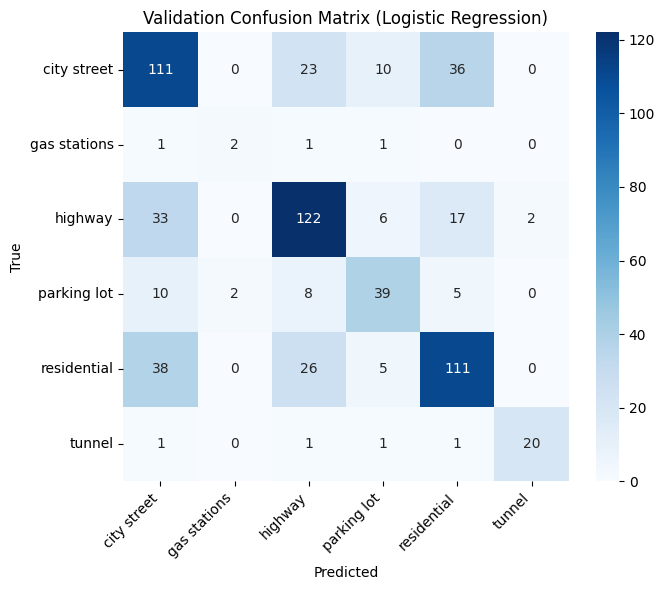

Accuracy: 0.6129541864139021
Precision: 0.6462907119920809
Recall: 0.6038773148148148
F1: 0.619095262493283


,precision,recall,f1-score,support
city street,0.571,0.533,0.552,180.000
gas stations,0.667,0.400,0.500,5.000
highway,0.596,0.606,0.601,180.000
parking lot,0.650,0.609,0.629,64.000
residential,0.634,0.683,0.658,180.000
tunnel,0.760,0.792,0.776,24.000
accuracy,0.613,0.613,0.613,0.613
macro avg,0.646,0.604,0.619,633.000
weighted avg,0.612,0.613,0.612,633.000


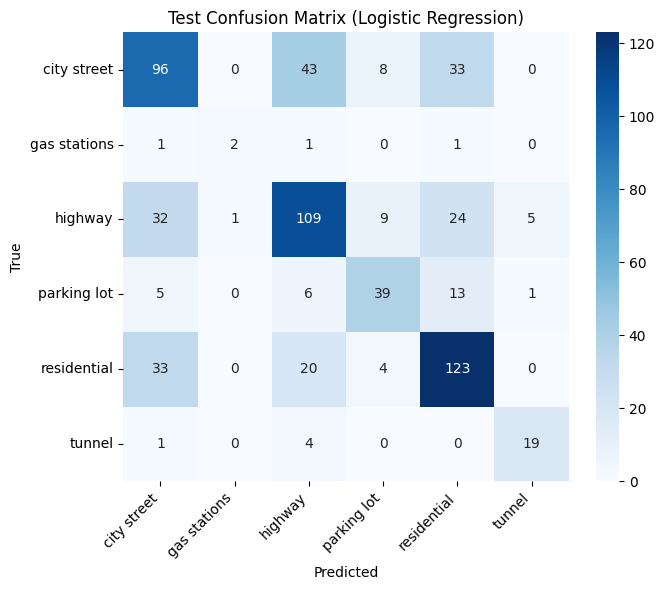

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, classification_report

X_train, X_val, X_test, y_train, y_val, y_test = get_splits('resnet', results, y)

log_model= LogisticRegression(solver = 'lbfgs')

log_model.fit(X_train, y_train)

y_val_pred = log_model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_val_pred)}")
print(f"Precision: {precision_score(y_val, y_val_pred, average='macro')}")
print(f"Recall: {recall_score(y_val, y_val_pred, average='macro')}")
print(f"F1: {f1_score(y_val, y_val_pred, average='macro')}")
cm = confusion_matrix(y_val, y_val_pred)
# print(cm)
# print( classification_report(y_val, y_val_pred))
print_classification_report(y_val, y_val_pred)
plot_confusion_matrix(y_val, y_val_pred, title="Validation Confusion Matrix (Logistic Regression)")


y_pred= log_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro')}")
print(f"Recall: {recall_score(y_test, y_pred, average='macro')}")
print(f"F1: {f1_score(y_test, y_pred, average='macro')}")
cm = confusion_matrix(y_test, y_pred)
# print(cm)
# print( classification_report(y_test, y_pred))
print_classification_report(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred, title="Test Confusion Matrix (Logistic Regression)")

Accuracy: 0.6666666666666666
Precision: 0.7461145296013717
Recall: 0.6591435185185185
F1: 0.6804025702523173
Validation Classification Report:


,precision,recall,f1-score,support
city street,0.626,0.594,0.610,180.000
gas stations,1.000,0.400,0.571,5.000
highway,0.686,0.706,0.696,180.000
parking lot,0.613,0.719,0.662,64.000
residential,0.676,0.661,0.669,180.000
tunnel,0.875,0.875,0.875,24.000
accuracy,0.667,0.667,0.667,0.667
macro avg,0.746,0.659,0.680,633.000
weighted avg,0.668,0.667,0.666,633.000


Validation Confusion Matrix:


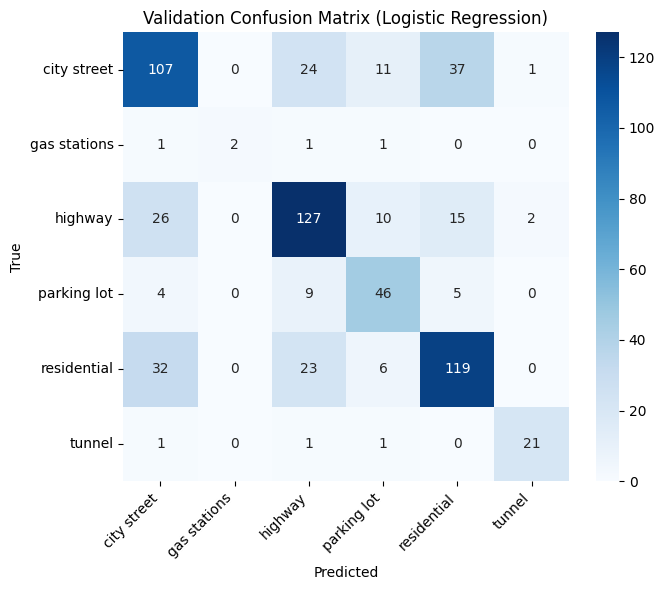

Accuracy: 0.6824644549763034
Precision: 0.7369541117226106
Recall: 0.6650462962962963
F1: 0.6746381252407169
Validation Classification Report:


,precision,recall,f1-score,support
city street,0.699,0.556,0.619,180.000
gas stations,1.000,0.400,0.571,5.000
highway,0.712,0.672,0.691,180.000
parking lot,0.688,0.688,0.688,64.000
residential,0.646,0.800,0.715,180.000
tunnel,0.677,0.875,0.764,24.000
accuracy,0.682,0.682,0.682,0.682
macro avg,0.737,0.665,0.675,633.000
weighted avg,0.688,0.682,0.679,633.000


Validation Confusion Matrix:


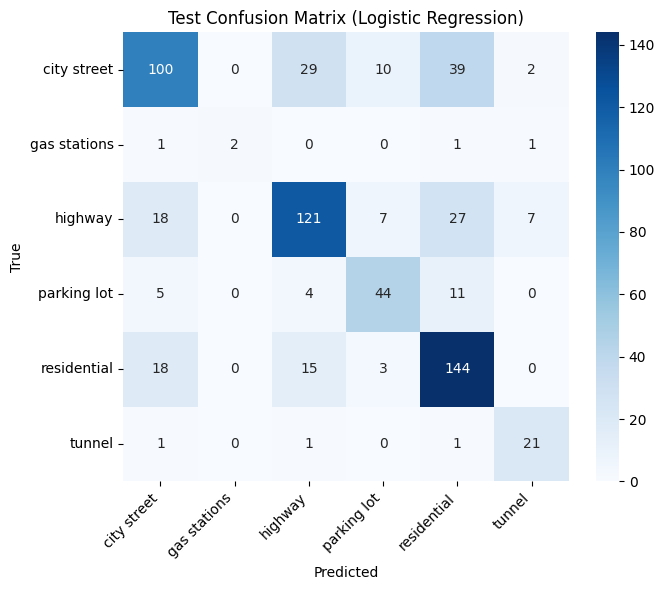

In [59]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, classification_report

X_train, X_val, X_test, y_train, y_val, y_test = get_splits('resnet', results, y)

svm_model= SVC(kernel = 'rbf', class_weight = 'balanced')

svm_model.fit(X_train, y_train)

y_val_pred = svm_model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_val_pred)}")
print(f"Precision: {precision_score(y_val, y_val_pred, average='macro')}")
print(f"Recall: {recall_score(y_val, y_val_pred, average='macro')}")
print(f"F1: {f1_score(y_val, y_val_pred, average='macro')}")
cm = confusion_matrix(y_val, y_val_pred)
print("Validation Classification Report:")
print_classification_report(y_val, y_val_pred)
print("Validation Confusion Matrix:")
plot_confusion_matrix(y_val, y_val_pred, title="Validation Confusion Matrix (Logistic Regression)")


y_pred= svm_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro')}")
print(f"Recall: {recall_score(y_test, y_pred, average='macro')}")
print(f"F1: {f1_score(y_test, y_pred, average='macro')}")
cm = confusion_matrix(y_test, y_pred)
print("Validation Classification Report:")
print_classification_report(y_test, y_pred)
print("Validation Confusion Matrix:")
plot_confusion_matrix(y_test, y_pred, title="Test Confusion Matrix (Logistic Regression)")

